# Molecular Graph Speed Benchmark

This notebook measures how `NSPPK.fit_transform(...)` runtime scales as the number of molecular graphs increases. It loads the dataset through `NSPPK.load_from(...)` so the graph construction path matches the shared library API.


In [5]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import RDLogger
from statsmodels.nonparametric.smoothers_lowess import lowess

REPO_CANDIDATES = [Path.cwd().resolve(), Path.cwd().resolve().parent]
REPO_ROOT = next(candidate for candidate in REPO_CANDIDATES if (candidate / 'src').exists())
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from nsppk import NSPPK

DATASET_URL = 'https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/HIV.csv'

NBIT = 14
RADIUS = 1
DISTANCE = 4
CONNECTOR = 1
BALANCE_DATASET = True
LIMIT = 5000
GRAPH_COUNT_VALUES = [250, 500, 2500, 5000]
N_REPEATS = 3
PARALLEL = True
RANDOM_STATE = 42

RDLogger.DisableLog('rdApp.*')


## Load molecular graphs

This notebook loads the molecular graphs directly through `NSPPK.load_from(...)` and reads the activity label from the CSV second column.


In [6]:
loader = NSPPK(radius=RADIUS, distance=DISTANCE, connector=CONNECTOR, nbits=NBIT, parallel=PARALLEL)
graphs = loader.load_from(
    DATASET_URL,
    'smiles',
    limit=LIMIT,
    random_state=RANDOM_STATE,
    balance=BALANCE_DATASET,
    label_extractor=lambda graph: int(graph.graph['name']),
)
labels = np.asarray([int(graph.graph['name']) for graph in graphs])

original_dataset_size = len(loader.load_from(DATASET_URL, 'smiles'))
available_graphs = len(graphs)
graph_count_values = [n for n in GRAPH_COUNT_VALUES if n <= available_graphs]
if graph_count_values[-1] != available_graphs:
    graph_count_values.append(available_graphs)

print('original loaded molecules:', original_dataset_size)
print('molecules used for speed benchmark:', available_graphs)
print('graph counts:', graph_count_values)
print('positive rate:', labels.mean())


original loaded molecules: 41120
molecules used for speed benchmark: 5000
graph counts: [250, 500, 2500, 5000]
positive rate: 0.2886


## Benchmark `fit_transform` runtime vs number of graphs

For each subset size, we instantiate a fresh `NSPPK` encoder and run `fit_transform` multiple times. The reported runtime is the mean over repeats.


In [7]:
results = []

print(f"{'graphs':>8} | {'repeat':>6} | {'seconds':>8} | {'sec/graph':>9}")
print('-' * 42)

for n_graphs in graph_count_values:
    subset_graphs = graphs[:n_graphs]
    runtimes = []

    for repeat_idx in range(1, N_REPEATS + 1):
        vectorizer = NSPPK(
            radius=RADIUS,
            distance=DISTANCE,
            connector=CONNECTOR,
            nbits=NBIT,
            dense=False,
            parallel=PARALLEL,
        )

        t0 = time.perf_counter()
        X = vectorizer.fit_transform(subset_graphs)
        runtime_sec = time.perf_counter() - t0
        runtimes.append(runtime_sec)

        print(f"{n_graphs:>8d} | {repeat_idx:>6d} | {runtime_sec:>8.2f} | {runtime_sec / n_graphs:>9.4f}")

    mean_runtime_sec = float(np.mean(runtimes))
    std_runtime_sec = float(np.std(runtimes, ddof=0))
    results.append(
        {
            'n_graphs': n_graphs,
            'mean_runtime_sec': mean_runtime_sec,
            'std_runtime_sec': std_runtime_sec,
            'mean_sec_per_graph': mean_runtime_sec / n_graphs,
            'n_features': X.shape[1],
            'parallel': PARALLEL,
            'nbits': NBIT,
        }
    )

results_df = pd.DataFrame(results)
results_df


  graphs | repeat |  seconds | sec/graph
------------------------------------------
     250 |      1 |    11.68 |    0.0467
     250 |      2 |    10.58 |    0.0423
     250 |      3 |    10.07 |    0.0403
     500 |      1 |    13.83 |    0.0277
     500 |      2 |    16.31 |    0.0326
     500 |      3 |    16.16 |    0.0323
    2500 |      1 |    44.23 |    0.0177
    2500 |      2 |    44.55 |    0.0178
    2500 |      3 |    49.28 |    0.0197
    5000 |      1 |    85.45 |    0.0171
    5000 |      2 |    94.60 |    0.0189
    5000 |      3 |    95.23 |    0.0190


,n_graphs,mean_runtime_sec,std_runtime_sec,mean_sec_per_graph,n_features,parallel,nbits
0,250,10.773748,0.673728,0.043095,16384,True,14
1,500,15.433274,1.136808,0.030867,16384,True,14
2,2500,46.017806,2.308257,0.018407,16384,True,14
3,5000,91.761915,4.470374,0.018352,16384,True,14


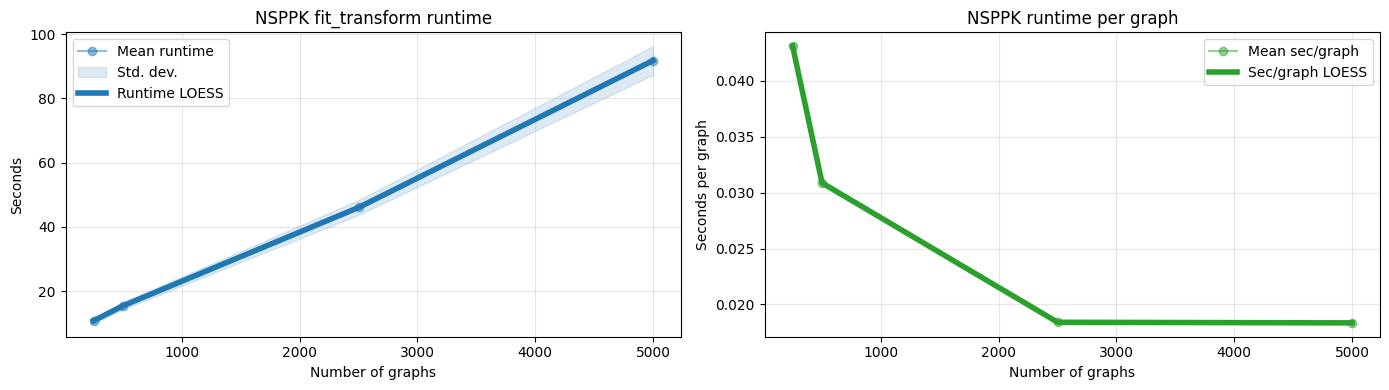

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x = results_df['n_graphs'].to_numpy()
runtime_values = results_df['mean_runtime_sec'].to_numpy()
sec_per_graph_values = results_df['mean_sec_per_graph'].to_numpy()

runtime_loess = lowess(runtime_values, x, frac=0.5, return_sorted=True)
sec_per_graph_loess = lowess(sec_per_graph_values, x, frac=0.5, return_sorted=True)

runtime_line, = axes[0].plot(x, runtime_values, marker='o', alpha=0.5, label='Mean runtime')
axes[0].fill_between(
    x,
    results_df['mean_runtime_sec'] - results_df['std_runtime_sec'],
    results_df['mean_runtime_sec'] + results_df['std_runtime_sec'],
    color=runtime_line.get_color(),
    alpha=0.15,
    label='Std. dev.',
)
axes[0].plot(runtime_loess[:, 0], runtime_loess[:, 1], color=runtime_line.get_color(), linewidth=4, alpha=1.0, label='Runtime LOESS')
axes[0].set_xlabel('Number of graphs')
axes[0].set_ylabel('Seconds')
axes[0].set_title('NSPPK fit_transform runtime')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

sec_line, = axes[1].plot(x, sec_per_graph_values, marker='o', alpha=0.5, color='tab:green', label='Mean sec/graph')
axes[1].plot(sec_per_graph_loess[:, 0], sec_per_graph_loess[:, 1], color=sec_line.get_color(), linewidth=4, alpha=1.0, label='Sec/graph LOESS')
axes[1].set_xlabel('Number of graphs')
axes[1].set_ylabel('Seconds per graph')
axes[1].set_title('NSPPK runtime per graph')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()
